# 動的LCA計算結果の可視化とCRF/DCFシミュレーション

Levasseur型のCRF・DCFの関係、RE2020近似、木材の炭素固定・将来放出ケース、Bernモデルパラメータ感度を可視化します。

## 1. 準備

ブラウザ上のJupyterでもプロジェクト内の `src` を参照できるようにし、日本語文字化け対策として `japanize_matplotlib` を読み込みます。

In [11]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

for module_name in ["dynamic_lca", "dynamic_lca.core"]:
    sys.modules.pop(module_name, None)

import matplotlib.pyplot as plt
import japanize_matplotlib
import ipywidgets as widgets
from IPython.display import Markdown, display

from dynamic_lca import (
    BernModel, GasModel, Flow,
    DEFAULT_CH4_MODEL, DEFAULT_N2O_MODEL,
    crf_co2, crf_gas,
    dcf_co2, dcf_gas, dcf_re2020,
    dynamic_gwp, impulse_response_co2, impulse_response_gas,
    static_gwp,
)

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 5)

print("日本語フォント設定が有効です。")
print("dynamic_lca import OK")
print(f"  CH4: lifetime={DEFAULT_CH4_MODEL.lifetime_years}年, RE={DEFAULT_CH4_MODEL.radiative_efficiency:.2e}")
print(f"  N2O: lifetime={DEFAULT_N2O_MODEL.lifetime_years}年, RE={DEFAULT_N2O_MODEL.radiative_efficiency:.2e}")

日本語フォント設定が有効です。
dynamic_lca import OK
  CH4: lifetime=12.4年, RE=1.28e-13
  N2O: lifetime=121.0年, RE=3.03e-13


## 2. CRF関数とDCF関数の関係

DCFは `DCF(t, HTI) = CRF(t, HTI) / CRF(0, HTI)` です。分母の `CRF(0, HTI)` は評価期間 `[0, HTI]` 全体を積分する固定基準であり、分子の `CRF(t, HTI)` は発生年 `t` から評価期間末まで、経過時間で表すと `[0, HTI - t]` だけを積分する可変値です。

下の図では、青い面積を分母、オレンジの面積を分子として表示します。`t` が大きくなるほどオレンジの積分範囲が短くなり、DCFが小さくなります。

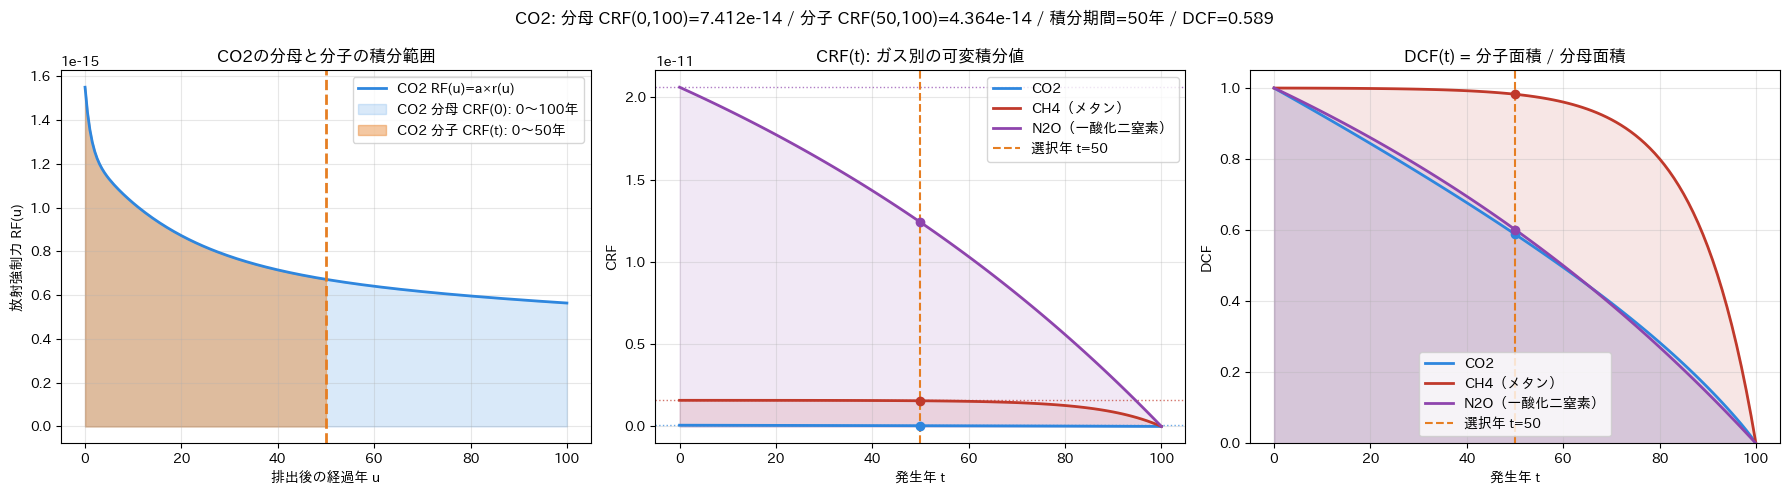


**CRF/DCFの読み方**

- **CO2分母**: `CRF(0, 100) = ∫[0, 100] RF(u) du = 7.412061e-14`
- **CO2分子**: `CRF(50, 100) = ∫[0, 50] RF(u) du = 4.364235e-14`
- **CO2 DCF**: `CRF(50, 100) / CRF(0, 100) = 0.588802`
- **意味**: 発生年 `t` が遅くなるほど、分子の積分範囲 `HTI - t` が短くなり、DCFが小さくなります。

**表示中のガス**

- **CO2**: `CRF(50)=4.364235e-14`, `DCF(50)=0.588802`
- **CH4（メタン）**: `CRF(50)=1.559263e-12`, `DCF(50)=0.982575`
- **N2O（一酸化二窒素）**: `CRF(50)=1.240991e-11`, `DCF(50)=0.601860`


In [12]:
GAS_STYLES = {
    "CO2": {"label": "CO2", "color": "#2e86de"},
    "CH4": {"label": "CH4（メタン）", "color": "#c0392b"},
    "N2O": {"label": "N2O（一酸化二窒素）", "color": "#8e44ad"},
}


def _selected_gases(show_co2=True, show_ch4=True, show_n2o=True):
    gases = []
    if show_co2:
        gases.append("CO2")
    if show_ch4:
        gases.append("CH4")
    if show_n2o:
        gases.append("N2O")
    return gases or ["CO2"]


def _rf_curve_values(duration, step_years, gas="CO2", model=None):
    count = int(duration / step_years) + 1
    xs = [min(i * step_years, duration) for i in range(count + 1)]
    if gas == "CO2" and model is not None:
        ys = [model.radiative_efficiency * impulse_response_co2(x, model=model) for x in xs]
    else:
        ys = [crf_gas(x, horizon_years=x + step_years, gas=gas, step_years=step_years) / step_years for x in xs]
    return xs, ys


def _gas_rf_values(xs, gas):
    return [crf_gas(x, horizon_years=x + 1, gas=gas, step_years=1.0) for x in xs]


def plot_crf_dcf_relationship(t=50, hti=100, step_years=0.5, show_co2=True, show_ch4=True, show_n2o=True):
    t = min(t, hti)
    gases = _selected_gases(show_co2, show_ch4, show_n2o)
    reference_crf = crf_co2(0, horizon_years=hti, step_years=step_years)
    selected_crf = crf_co2(t, horizon_years=hti, step_years=step_years)
    selected_dcf = dcf_co2(t, horizon_years=hti, step_years=step_years)
    numerator_duration = hti - t

    elapsed_years, rf_values = _rf_curve_values(hti, step_years, "CO2", BernModel())
    numerator_x = [x for x in elapsed_years if x <= numerator_duration]
    numerator_y = rf_values[: len(numerator_x)]
    occurrence_years = list(range(0, int(hti) + 1))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(elapsed_years, rf_values, color="#2e86de", linewidth=2, label="CO2 RF(u)=a×r(u)")
    axes[0].fill_between(elapsed_years, rf_values, color="#2e86de", alpha=0.18, label=f"CO2 分母 CRF(0): 0〜{hti}年")
    axes[0].fill_between(numerator_x, numerator_y, color="#e67e22", alpha=0.42, label=f"CO2 分子 CRF(t): 0〜{numerator_duration}年")
    axes[0].axvline(numerator_duration, color="#e67e22", linestyle="--", linewidth=2)
    axes[0].set_title("CO2の分母と分子の積分範囲")
    axes[0].set_xlabel("排出後の経過年 u")
    axes[0].set_ylabel("放射強制力 RF(u)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    for gas in gases:
        style = GAS_STYLES[gas]
        crf_values = [crf_gas(year, horizon_years=hti, gas=gas, step_years=step_years) for year in occurrence_years]
        selected_gas_crf = crf_gas(t, horizon_years=hti, gas=gas, step_years=step_years)
        reference_gas_crf = crf_gas(0, horizon_years=hti, gas=gas, step_years=step_years)
        axes[1].plot(occurrence_years, crf_values, color=style["color"], linewidth=2, label=style["label"])
        axes[1].fill_between(occurrence_years, crf_values, color=style["color"], alpha=0.12)
        axes[1].scatter([t], [selected_gas_crf], color=style["color"], zorder=3)
        axes[1].axhline(reference_gas_crf, color=style["color"], linestyle=":", linewidth=1, alpha=0.7)
    axes[1].axvline(t, color="#e67e22", linestyle="--", label=f"選択年 t={t}")
    axes[1].set_title("CRF(t): ガス別の可変積分値")
    axes[1].set_xlabel("発生年 t")
    axes[1].set_ylabel("CRF")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    for gas in gases:
        style = GAS_STYLES[gas]
        dcf_values = [dcf_gas(year, horizon_years=hti, gas=gas, step_years=step_years) for year in occurrence_years]
        selected_gas_dcf = dcf_gas(t, horizon_years=hti, gas=gas, step_years=step_years)
        axes[2].plot(occurrence_years, dcf_values, color=style["color"], linewidth=2, label=style["label"])
        axes[2].fill_between(occurrence_years, dcf_values, color=style["color"], alpha=0.12)
        axes[2].scatter([t], [selected_gas_dcf], color=style["color"], zorder=3)
    axes[2].axvline(t, color="#e67e22", linestyle="--", label=f"選択年 t={t}")
    axes[2].set_title("DCF(t) = 分子面積 / 分母面積")
    axes[2].set_xlabel("発生年 t")
    axes[2].set_ylabel("DCF")
    axes[2].set_ylim(0, 1.05)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.suptitle(
        f"CO2: 分母 CRF(0,{hti})={reference_crf:.3e} / 分子 CRF({t},{hti})={selected_crf:.3e} / "
        f"積分期間={numerator_duration}年 / DCF={selected_dcf:.3f}"
    )
    plt.tight_layout()
    plt.show()

    gas_rows = "\n".join(
        [f"- **{GAS_STYLES[gas]['label']}**: `CRF({t})={crf_gas(t, horizon_years=hti, gas=gas, step_years=step_years):.6e}`, `DCF({t})={dcf_gas(t, horizon_years=hti, gas=gas, step_years=step_years):.6f}`" for gas in gases]
    )
    display(Markdown(f"""
**CRF/DCFの読み方**

- **CO2分母**: `CRF(0, {hti}) = ∫[0, {hti}] RF(u) du = {reference_crf:.6e}`
- **CO2分子**: `CRF({t}, {hti}) = ∫[0, {numerator_duration}] RF(u) du = {selected_crf:.6e}`
- **CO2 DCF**: `CRF({t}, {hti}) / CRF(0, {hti}) = {selected_dcf:.6f}`
- **意味**: 発生年 `t` が遅くなるほど、分子の積分範囲 `HTI - t` が短くなり、DCFが小さくなります。

**表示中のガス**

{gas_rows}
"""))

plot_crf_dcf_relationship()

## 3a. IRF → CRF：積分範囲を広げるほどCRFが増える過程

CRF（累積放射強制力）は、IRF（インパルス応答関数）に放射効率 `a` を掛けた被積分関数を `[0, s]` の範囲で積分したものです。

$$\text{CRF}(0, s) = \int_0^s a \cdot r(u)\, du$$

**左図の塗りつぶし面積**が、そのまま**右図のCRF値**に対応します。
スライダーで積分上限 `s` を変化させると、積分範囲が広がるにつれてCRFが増加する様子を確認できます。

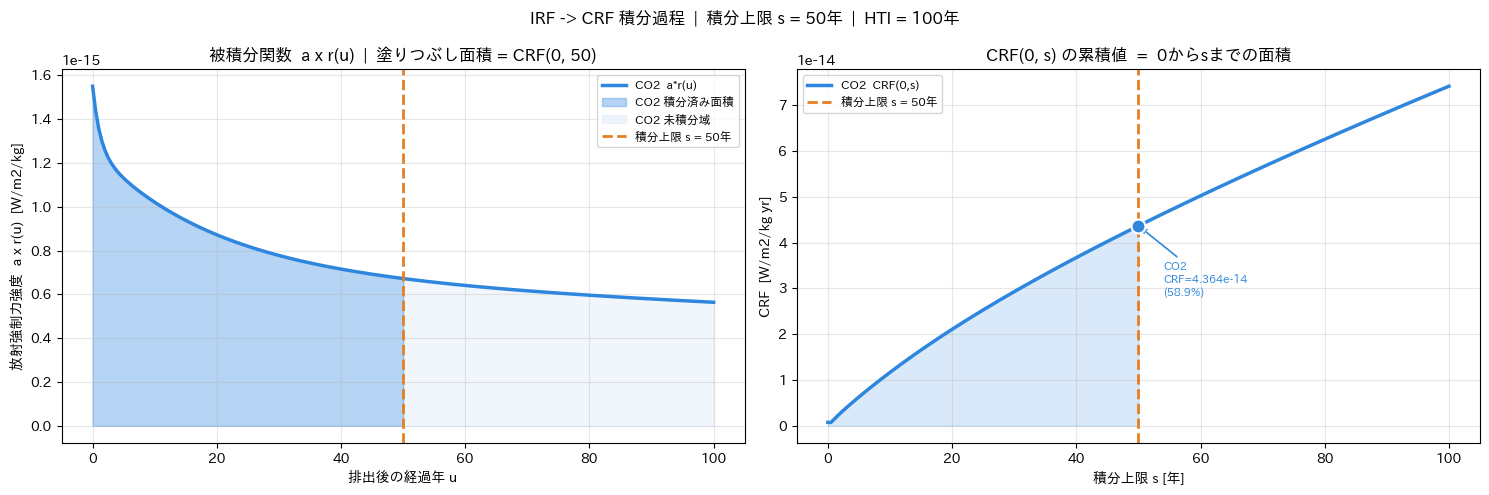


**積分値サマリー（積分上限 s = 50年 / HTI = 100年）**

| ガス | CRF(0, 50) | CRF(0, 100) =分母 | 進捗 |
|------|-----------|-----------|------|
| CO2 | `4.3642e-14` | `7.4121e-14` | **58.9%** |

> **読み方**: 左図の**塗りつぶし面積**が CRF の数値に直接対応します。
> s を HTI まで広げると CRF が最大値（分母）に達し、DCF = CRF(t, HTI) / CRF(0, HTI) = 1.0 になります（t=0 のとき）。


interactive(children=(IntSlider(value=50, description='積分上限 s', max=200, min=1, style=SliderStyle(description_…

In [13]:
def plot_crf_accumulation(upper_s=50, hti=100, step_years=0.5,
                          show_co2=True, show_ch4=False, show_n2o=False):
    """
    IRFを積分してCRFが累積していく過程を可視化する。
    左: 被積分関数 a × r(u) — 塗りつぶし面積が CRF の値
    右: CRF(0, s) = ∫[0→s] a×r(u)du の累積曲線
    """
    model = BernModel()
    upper_s = float(min(upper_s, hti))

    gases = []
    if show_co2: gases.append("CO2")
    if show_ch4: gases.append("CH4")
    if show_n2o: gases.append("N2O")
    if not gases:
        gases = ["CO2"]

    n = int(hti / step_years)
    s_vals = [i * step_years for i in range(n + 1)]
    idx_s = min(range(len(s_vals)), key=lambda i: abs(s_vals[i] - upper_s))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for gas in gases:
        style = GAS_STYLES[gas]
        color = style["color"]
        label = style["label"]

        # 被積分関数 a × r(u)
        if gas == "CO2":
            re = model.radiative_efficiency
            integrand = [re * impulse_response_co2(u, model=model) for u in s_vals]
        else:
            gas_model = DEFAULT_CH4_MODEL if gas == "CH4" else DEFAULT_N2O_MODEL
            re = gas_model.radiative_efficiency
            integrand = [re * impulse_response_gas(u, gas=gas) for u in s_vals]

        # 累積CRF: crf_gas(0, s) = ∫[0→s] a·r(u) du
        cum_crf = [crf_gas(0.0, max(s, step_years), gas=gas, step_years=step_years) for s in s_vals]
        current_crf = cum_crf[idx_s]
        total_crf = cum_crf[-1]

        # --- 左パネル: 被積分関数と塗りつぶし面積 ---
        axes[0].plot(s_vals, integrand, color=color, linewidth=2.5, label=f"{label}  a*r(u)")
        axes[0].fill_between(
            s_vals[:idx_s + 1], integrand[:idx_s + 1],
            color=color, alpha=0.35, label=f"{label} 積分済み面積"
        )
        if idx_s < len(s_vals) - 1:
            axes[0].fill_between(
                s_vals[idx_s:], integrand[idx_s:],
                color=color, alpha=0.07, label=f"{label} 未積分域"
            )

        # --- 右パネル: CRF累積曲線 ---
        axes[1].plot(s_vals, cum_crf, color=color, linewidth=2.5, label=f"{label}  CRF(0,s)")
        axes[1].fill_between(s_vals[:idx_s + 1], cum_crf[:idx_s + 1], color=color, alpha=0.18)
        axes[1].scatter([upper_s], [current_crf], color=color, zorder=6, s=100,
                        edgecolors="white", linewidths=1.5)

        # 現在値のアノテーション
        x_off = hti * 0.04 if upper_s < hti * 0.75 else -hti * 0.35
        axes[1].annotate(
            f"{label}\nCRF={current_crf:.3e}\n({current_crf / total_crf * 100:.1f}%)",
            xy=(upper_s, current_crf),
            xytext=(upper_s + x_off, current_crf * 0.65),
            fontsize=8, color=color,
            arrowprops=dict(arrowstyle="->", color=color, lw=1.2),
        )

    # 積分上限の縦線（共通）
    axes[0].axvline(upper_s, color="#e67e22", linestyle="--", linewidth=2,
                    label=f"積分上限 s = {upper_s:.0f}年")
    axes[1].axvline(upper_s, color="#e67e22", linestyle="--", linewidth=2,
                    label=f"積分上限 s = {upper_s:.0f}年")

    axes[0].set_title(f"被積分関数  a x r(u)  |  塗りつぶし面積 = CRF(0, {upper_s:.0f})")
    axes[0].set_xlabel("排出後の経過年 u")
    axes[0].set_ylabel("放射強制力強度  a x r(u)  [W/m2/kg]")
    axes[0].legend(fontsize=8.5)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"CRF(0, s) の累積値  =  0からsまでの面積")
    axes[1].set_xlabel("積分上限 s [年]")
    axes[1].set_ylabel("CRF  [W/m2/kg yr]")
    axes[1].legend(fontsize=8.5)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f"IRF -> CRF 積分過程  |  積分上限 s = {upper_s:.0f}年  |  HTI = {hti:.0f}年",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    # サマリーテーブル
    rows = []
    for gas in gases:
        current = crf_gas(0.0, max(upper_s, step_years), gas=gas, step_years=step_years)
        total   = crf_gas(0.0, hti, gas=gas, step_years=step_years)
        rows.append(
            f"| {GAS_STYLES[gas]['label']} | `{current:.4e}` | `{total:.4e}` | **{current/total*100:.1f}%** |"
        )

    display(Markdown(f"""
**積分値サマリー（積分上限 s = {upper_s:.0f}年 / HTI = {hti:.0f}年）**

| ガス | CRF(0, {upper_s:.0f}) | CRF(0, {hti:.0f}) =分母 | 進捗 |
|------|-----------|-----------|------|
{chr(10).join(rows)}

> **読み方**: 左図の**塗りつぶし面積**が CRF の数値に直接対応します。
> s を HTI まで広げると CRF が最大値（分母）に達し、DCF = CRF(t, HTI) / CRF(0, HTI) = 1.0 になります（t=0 のとき）。
"""))


# 静的表示（デフォルト値）
plot_crf_accumulation(upper_s=50, hti=100)

# インタラクティブ表示
widgets.interact(
    plot_crf_accumulation,
    upper_s=widgets.IntSlider(value=50, min=1, max=200, step=1,
                              description="積分上限 s", style={"description_width": "90px"}),
    hti=widgets.IntSlider(value=100, min=20, max=200, step=5, description="HTI"),
    step_years=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description="刻み"),
    show_co2=widgets.Checkbox(value=True,  description="CO2"),
    show_ch4=widgets.Checkbox(value=False, description="CH4"),
    show_n2o=widgets.Checkbox(value=False, description="N2O"),
);

## 3. CRF/DCF関係のインタラクティブ表示

`t`、`HTI`、数値積分刻みをスライダーで変更し、CRFとDCFの関係がどう変わるかを確認します。

## 4. Bernモデルパラメータ感度と木材GWPの前提別比較

Bernモデルの係数と時定数を変更し、インパルス応答、CRF、DCF、木材ケースの動的GWPへの影響を確認します。

木材ケースでは、`-1/+1` アプローチのもとで `-100 kgCO2` の固定と `+100 kgCO2` の将来放出を同時に扱います。静的GWPでは時間を区別しないため `-100 + 100 = 0` になります。一方、動的GWPでは固定は `DCF(0)=1`、将来放出は `DCF(DO)<1` で重み付けされるため、完全には相殺されません。

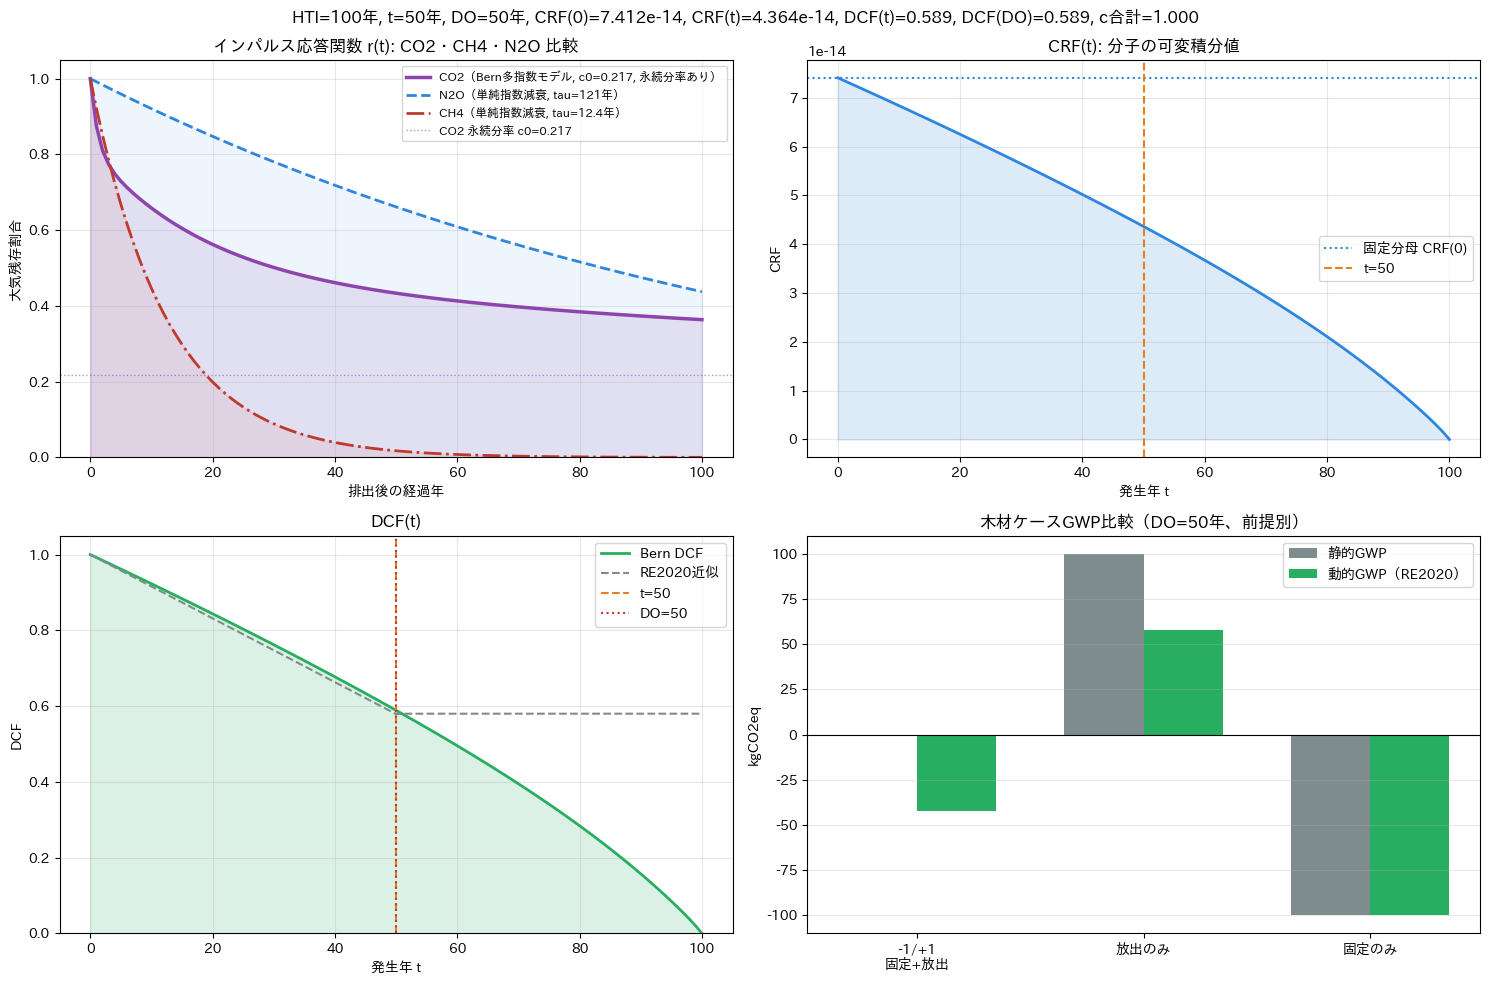


**計算値の要約**

- **CRF(0)**: `7.412061e-14`
- **CRF(50)**: `4.364235e-14`
- **DCF(50) = CRF(50) / CRF(0)**: `0.588802`
- **c0+c1+c2+c3**: `1.000`

**インパルス応答の比較（t=50年時点）**

| ガス | モデル | 大気残存割合 r(50) | 特徴 |
|------|--------|-------------------|------|
| CO2 | Bern多指数（AR4） | 0.4336 | 永続分率 c0=0.217 が残存 |
| N2O | 単純指数（tau=121年） | 0.6615 | tauが長いので緩やかに減衰 |
| CH4 | 単純指数（tau=12.4年） | 0.0177 | 短命なので急速に減衰 |

**なぜ静的GWPが0になるか**

- **前提**: `-1/+1` アプローチでは、製造時の炭素固定 `-100 kgCO2` と使用後の放出 `+100 kgCO2` を両方計上します。
- **静的GWP**: `(-100x1) + (100x1) = 0.000 kgCO2eq`
- **動的GWP（Bern）**: `(-100xDCF(0)) + (100xDCF(50)) = -100x1 + 100x0.588802 = -41.120 kgCO2eq`
- **解釈**: 静的LCAは時間を区別しないため等量なら相殺されます。動的LCAは将来放出を `DCF(DO)<1` で重み付けするため、固定と放出が完全には相殺されません。

**-1/+1ケースのフロー別寄与**

`[{'区分': 'A1-A3', '名称': 'バイオジェニック炭素固定', '発生年': 0, '量 kgCO2': -100, '静的寄与': -100.0, 'DCF Bern': 1.0, '動的寄与 Bern': -100.0, 'DCF RE2020': 1.0, '動的寄与 RE2020': -100.0}, {'区分': 'C', '名称': '使用後の炭素放出', '発生年': 50, '量 kgCO2': 100, '静的寄与': 100.0, 'DCF Bern': 0.588802, '動的寄与 Bern': 58.88, 'DCF RE2020': 0.579, '動的寄与 RE2020': 57.9}]`


In [14]:
def _wood_case_scenarios(do):
    return {
        "-1/+1\n固定+放出": [
            Flow(year=0, amount=-100, name="バイオジェニック炭素固定", category="A1-A3"),
            Flow(year=do, amount=100, name="使用後の炭素放出", category="C"),
        ],
        "放出のみ": [
            Flow(year=do, amount=100, name="使用後の炭素放出", category="C"),
        ],
        "固定のみ": [
            Flow(year=0, amount=-100, name="バイオジェニック炭素固定", category="A1-A3"),
        ],
    }


def _flow_contribution_rows(flows, hti, step_years, model):
    rows = []
    for flow in flows:
        bern_dcf = dcf_co2(flow.year, horizon_years=hti, step_years=step_years, model=model)
        re2020_dcf = dcf_re2020(flow.year)
        rows.append(
            {
                "区分": flow.category,
                "名称": flow.name,
                "発生年": flow.year,
                "量 kgCO2": flow.amount,
                "静的寄与": round(flow.amount * flow.gwp, 3),
                "DCF Bern": round(bern_dcf, 6),
                "動的寄与 Bern": round(flow.amount * flow.gwp * bern_dcf, 3),
                "DCF RE2020": round(re2020_dcf, 6),
                "動的寄与 RE2020": round(flow.amount * flow.gwp * re2020_dcf, 3),
            }
        )
    return rows


def simulate_bern_sensitivity(
    t=50,
    do=50,
    hti=100,
    step_years=0.5,
    c0=0.217,
    c1=0.259,
    c2=0.338,
    c3=0.186,
    tau1=172.9,
    tau2=18.51,
    tau3=1.186,
    radiative_efficiency=1.55e-15,
):
    model = BernModel(
        c0=c0,
        c1=c1,
        c2=c2,
        c3=c3,
        tau1=tau1,
        tau2=tau2,
        tau3=tau3,
        radiative_efficiency=radiative_efficiency,
    )
    years = list(range(0, int(hti) + 1))

    # --- インパルス応答: CO2（Bernモデル）・CH4・N2O ---
    co2_response = [impulse_response_co2(year, model=model) for year in years]
    ch4_response = [impulse_response_gas(year, gas="CH4") for year in years]
    n2o_response = [impulse_response_gas(year, gas="N2O") for year in years]

    crf_values = [crf_co2(year, horizon_years=hti, step_years=step_years, model=model) for year in years]
    dcf_values = [dcf_co2(year, horizon_years=hti, step_years=step_years, model=model) for year in years]

    scenarios = _wood_case_scenarios(do)
    scenario_results = {
        name: {
            "静的GWP": static_gwp(flows),
            "動的GWP（Bern）": dynamic_gwp(flows, method="bern", horizon_years=hti, step_years=step_years, model=model),
            "動的GWP（RE2020）": dynamic_gwp(flows, method="re2020"),
        }
        for name, flows in scenarios.items()
    }
    base_flows = scenarios["-1/+1\n固定+放出"]
    base_results = scenario_results["-1/+1\n固定+放出"]
    contribution_rows = _flow_contribution_rows(base_flows, hti, step_years, model)

    selected_crf = crf_co2(t, horizon_years=hti, step_years=step_years, model=model)
    reference_crf = crf_co2(0, horizon_years=hti, step_years=step_years, model=model)
    selected_dcf = dcf_co2(t, horizon_years=hti, step_years=step_years, model=model)
    do_dcf = dcf_co2(do, horizon_years=hti, step_years=step_years, model=model)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # --- axes[0,0]: インパルス応答 CO2 / CH4 / N2O 比較 ---
    axes[0, 0].plot(years, co2_response, color="#8e44ad", linewidth=2.5,
                    label=f"CO2（Bern多指数モデル, c0={c0:.3f}, 永続分率あり）")
    axes[0, 0].fill_between(years, co2_response, color="#8e44ad", alpha=0.12)
    axes[0, 0].plot(years, n2o_response, color="#2e86de", linewidth=2, linestyle="--",
                    label="N2O（単純指数減衰, tau=121年）")
    axes[0, 0].fill_between(years, n2o_response, color="#2e86de", alpha=0.08)
    axes[0, 0].plot(years, ch4_response, color="#c0392b", linewidth=2, linestyle="-.",
                    label="CH4（単純指数減衰, tau=12.4年）")
    axes[0, 0].fill_between(years, ch4_response, color="#c0392b", alpha=0.08)
    axes[0, 0].axhline(c0, color="#8e44ad", linestyle=":", linewidth=1, alpha=0.6,
                       label=f"CO2 永続分率 c0={c0:.3f}")
    axes[0, 0].set_title("インパルス応答関数 r(t): CO2・CH4・N2O 比較")
    axes[0, 0].set_xlabel("排出後の経過年")
    axes[0, 0].set_ylabel("大気残存割合")
    axes[0, 0].set_ylim(0, 1.05)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend(fontsize=8.5)

    axes[0, 1].plot(years, crf_values, color="#2e86de", linewidth=2)
    axes[0, 1].fill_between(years, crf_values, color="#2e86de", alpha=0.16)
    axes[0, 1].axhline(reference_crf, color="#2e86de", linestyle=":", label="固定分母 CRF(0)")
    axes[0, 1].axvline(t, color="#e67e22", linestyle="--", label=f"t={t}")
    axes[0, 1].set_title("CRF(t): 分子の可変積分値")
    axes[0, 1].set_xlabel("発生年 t")
    axes[0, 1].set_ylabel("CRF")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    axes[1, 0].plot(years, dcf_values, color="#27ae60", linewidth=2, label="Bern DCF")
    axes[1, 0].fill_between(years, dcf_values, color="#27ae60", alpha=0.16)
    axes[1, 0].plot(years, [dcf_re2020(year) for year in years], color="#7f8c8d", linestyle="--", label="RE2020近似")
    axes[1, 0].axvline(t, color="#e67e22", linestyle="--", label=f"t={t}")
    axes[1, 0].axvline(do, color="#c0392b", linestyle=":", label=f"DO={do}")
    axes[1, 0].set_title("DCF(t)")
    axes[1, 0].set_xlabel("発生年 t")
    axes[1, 0].set_ylabel("DCF")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # --- axes[1,1]: 木材ケースGWP比較（静的GWP と RE2020動的GWPのみ）---
    x_labels = list(scenario_results.keys())
    x_positions = list(range(len(x_labels)))
    width = 0.35
    static_values  = [scenario_results[name]["静的GWP"]        for name in x_labels]
    re2020_values  = [scenario_results[name]["動的GWP（RE2020）"] for name in x_labels]
    axes[1, 1].bar([x - width / 2 for x in x_positions], static_values,
                   width=width, label="静的GWP", color="#7f8c8d")
    axes[1, 1].bar([x + width / 2 for x in x_positions], re2020_values,
                   width=width, label="動的GWP（RE2020）", color="#27ae60")
    axes[1, 1].axhline(0, color="black", linewidth=0.8)
    axes[1, 1].set_title(f"木材ケースGWP比較（DO={do}年、前提別）")
    axes[1, 1].set_ylabel("kgCO2eq")
    axes[1, 1].set_xticks(x_positions)
    axes[1, 1].set_xticklabels(x_labels)
    axes[1, 1].grid(True, axis="y", alpha=0.3)
    axes[1, 1].legend()

    coefficient_sum = c0 + c1 + c2 + c3
    ch4_at_t = impulse_response_gas(t, gas="CH4")
    n2o_at_t = impulse_response_gas(t, gas="N2O")
    fig.suptitle(
        f"HTI={hti}年, t={t}年, DO={do}年, CRF(0)={reference_crf:.3e}, "
        f"CRF(t)={selected_crf:.3e}, DCF(t)={selected_dcf:.3f}, DCF(DO)={do_dcf:.3f}, c合計={coefficient_sum:.3f}"
    )
    plt.tight_layout()
    plt.show()

    static_formula = " + ".join([f"({flow.amount:.0f}x{flow.gwp:.0f})" for flow in base_flows])
    dynamic_formula = f"(-100xDCF(0)) + (100xDCF({do})) = -100x1 + 100x{do_dcf:.6f}"
    display(Markdown(f"""
**計算値の要約**

- **CRF(0)**: `{reference_crf:.6e}`
- **CRF({t})**: `{selected_crf:.6e}`
- **DCF({t}) = CRF({t}) / CRF(0)**: `{selected_dcf:.6f}`
- **c0+c1+c2+c3**: `{coefficient_sum:.3f}`

**インパルス応答の比較（t={t}年時点）**

| ガス | モデル | 大気残存割合 r({t}) | 特徴 |
|------|--------|-------------------|------|
| CO2 | Bern多指数（AR4） | {co2_response[min(t, hti)]:.4f} | 永続分率 c0={c0:.3f} が残存 |
| N2O | 単純指数（tau=121年） | {n2o_at_t:.4f} | tauが長いので緩やかに減衰 |
| CH4 | 単純指数（tau=12.4年） | {ch4_at_t:.4f} | 短命なので急速に減衰 |

**なぜ静的GWPが0になるか**

- **前提**: `-1/+1` アプローチでは、製造時の炭素固定 `-100 kgCO2` と使用後の放出 `+100 kgCO2` を両方計上します。
- **静的GWP**: `{static_formula} = {base_results['静的GWP']:.3f} kgCO2eq`
- **動的GWP（Bern）**: `{dynamic_formula} = {base_results['動的GWP（Bern）']:.3f} kgCO2eq`
- **解釈**: 静的LCAは時間を区別しないため等量なら相殺されます。動的LCAは将来放出を `DCF(DO)<1` で重み付けするため、固定と放出が完全には相殺されません。

**-1/+1ケースのフロー別寄与**

`{contribution_rows}`
"""))

simulate_bern_sensitivity()

## 4b. 木造建築物 LCAケース：段階別・ライフサイクル計 GWP 比較

画像テーブルのケース（製品製造-600 / 施工+30 / 解体+700 kg-CO2eq）を対象に、
静的GWP と 動的GWP（RE2020）を段階別および合計で比較します。

| LCA段階 | 静的値 | 適用係数 | 動的値 |
|---------|--------|---------|--------|
| 製品製造（吸収含む） | -600 | t=0, ×1.0 | -600 |
| 施工 | +30 | t=0, ×1.0 | +30 |
| 使用（1〜49年） | 0 | — | 0 |
| 解体・廃棄（50年） | +700 | t=50, ×0.578 | +404.6 |
| **ライフサイクル計** | **+130** | — | **-165.4** |

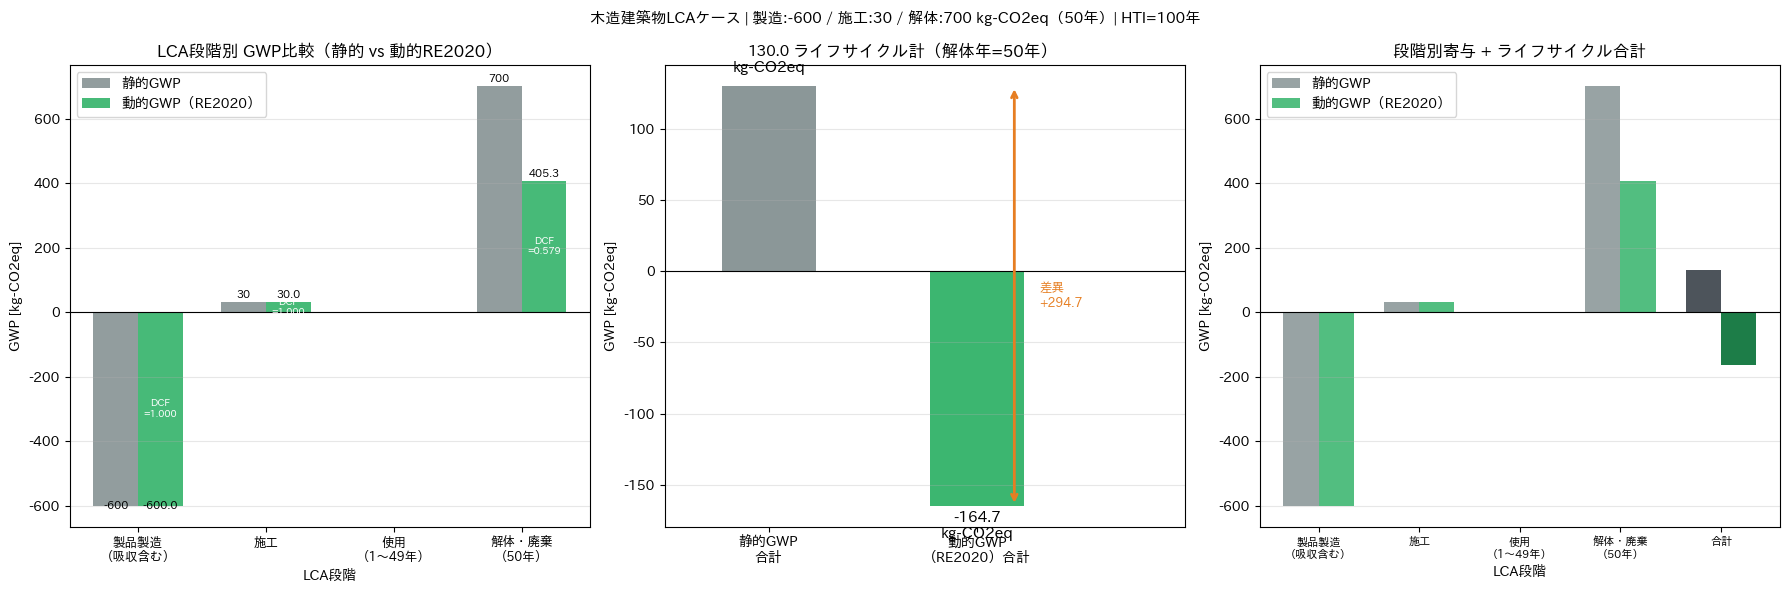


**計算結果サマリー**

| LCA段階 | 静的値 (kg-CO2eq) | 適用係数 | 動的値 (kg-CO2eq) |
|---------|----------|---------|---------|
| 製品製造 （吸収含む） | -600 | t=0, x1.000 | -600.0 |
| 施工 | +30 | t=0, x1.000 | +30.0 |
| 使用 （1〜49年） | +0 | t=—, x— | +0.0 |
| 解体・廃棄 （50年） | +700 | t=50, x0.579 | +405.3 |
| **ライフサイクル計** | **+130.0** | — | **-164.7** |

> 動的GWPは静的GWP比で **-294.7 kg-CO2eq** の差異。
> 解体廃棄（+700）の DCF=0.579 による割り引きが主因。


interactive(children=(IntSlider(value=-600, description='製造+吸収', max=0, min=-1500, step=10, style=SliderStyle(…

In [18]:
def plot_building_lca_gwp(
    amount_manufacture=-600,
    amount_construction=30,
    amount_use=0,
    amount_demolition=700,
    year_demolition=50,
    hti=100,
    step_years=0.5,
):
    """
    木造建築物LCAケースの静的GWP vs 動的GWP（RE2020）を可視化する。
    左: LCA段階別グループ棒グラフ
    右: ライフサイクル計の比較 + ウォーターフォール
    """
    # --- 各段階のDCF（RE2020）と動的寄与を計算 ---
    stages_def = [
        {"name": "製品製造\n（吸収含む）", "year": 0,               "amount": amount_manufacture},
        {"name": "施工",                   "year": 0,               "amount": amount_construction},
        {"name": f"使用\n（1〜{year_demolition-1}年）",
                                           "year": None,            "amount": amount_use},
        {"name": f"解体・廃棄\n（{year_demolition}年）",
                                           "year": year_demolition, "amount": amount_demolition},
    ]

    for s in stages_def:
        s["static"] = float(s["amount"])
        if s["year"] is None:
            s["dcf"] = None
            s["dynamic"] = 0.0
        else:
            s["dcf"] = dcf_re2020(s["year"])
            s["dynamic"] = s["amount"] * s["dcf"]

    total_static  = sum(s["static"]  for s in stages_def)
    total_dynamic = sum(s["dynamic"] for s in stages_def)

    # --- レイアウト: 1行3列 ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    stage_names   = [s["name"]    for s in stages_def]
    static_vals   = [s["static"]  for s in stages_def]
    dynamic_vals  = [s["dynamic"] for s in stages_def]
    x = list(range(len(stages_def)))
    width = 0.35

    # ---- 左パネル: 段階別グループ棒グラフ ----
    bars_s = axes[0].bar([xi - width / 2 for xi in x], static_vals,
                          width, label="静的GWP", color="#7f8c8d", alpha=0.85)
    bars_d = axes[0].bar([xi + width / 2 for xi in x], dynamic_vals,
                          width, label="動的GWP（RE2020）", color="#27ae60", alpha=0.85)

    def _label(ax, bars, fmt="{:.0f}"):
        for bar in bars:
            h = bar.get_height()
            if abs(h) < 1e-9:
                continue
            y_pos = h + (8 if h >= 0 else -18)
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                    fmt.format(h), ha="center", va="bottom", fontsize=8)

    _label(axes[0], bars_s)
    _label(axes[0], bars_d, "{:.1f}")

    # DCF値をバーの中に表示
    for i, s in enumerate(stages_def):
        if s["dcf"] is not None:
            axes[0].text(i + width / 2, dynamic_vals[i] / 2,
                         f"DCF\n={s['dcf']:.3f}", ha="center", va="center",
                         fontsize=7, color="white", fontweight="bold")

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("LCA段階別 GWP比較（静的 vs 動的RE2020）")
    axes[0].set_xlabel("LCA段階")
    axes[0].set_ylabel("GWP [kg-CO2eq]")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(stage_names, fontsize=9)
    axes[0].legend()
    axes[0].grid(True, axis="y", alpha=0.3)

    # ---- 中パネル: ライフサイクル計の比較 ----
    totals  = [total_static, total_dynamic]
    colors  = ["#7f8c8d", "#27ae60"]
    clabels = ["静的GWP\n合計", "動的GWP\n（RE2020）合計"]
    bars_t  = axes[1].bar(clabels, totals, width=0.45, color=colors, alpha=0.9)

    for bar, val in zip(bars_t, totals):
        offset = 8 if val >= 0 else -25
        axes[1].text(bar.get_x() + bar.get_width() / 2, val + offset,
                     f"{val:.1f}\nkg-CO2eq",
                     ha="center", va="bottom", fontsize=11, fontweight="bold")

    # 差分の両矢印
    reduction = total_static - total_dynamic
    mid_x = 0.5
    axes[1].annotate("", xy=(1.18, total_dynamic), xytext=(1.18, total_static),
                     arrowprops=dict(arrowstyle="<->", color="#e67e22", lw=2.0))
    axes[1].text(1.30, (total_static + total_dynamic) / 2,
                 f"差異\n{reduction:+.1f}", ha="left", va="center",
                 fontsize=9, color="#e67e22", fontweight="bold")

    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"ライフサイクル計（解体年={year_demolition}年）")
    axes[1].set_ylabel("GWP [kg-CO2eq]")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].set_xlim(-0.5, 2.0)

    # ---- 右パネル: ウォーターフォール（累積積み上げ） ----
    wf_labels = [s["name"] for s in stages_def] + ["合計"]
    wf_static  = static_vals  + [total_static]
    wf_dynamic = dynamic_vals + [total_dynamic]

    wf_x = list(range(len(wf_labels)))
    axes[2].bar([xi - width / 2 for xi in wf_x], wf_static,
                width, label="静的GWP", color="#7f8c8d", alpha=0.80)
    axes[2].bar([xi + width / 2 for xi in wf_x], wf_dynamic,
                width, label="動的GWP（RE2020）", color="#27ae60", alpha=0.80)

    # 合計バーを強調
    axes[2].bar([len(wf_labels) - 1 - width / 2], [total_static],
                width, color="#495057", alpha=0.95)
    axes[2].bar([len(wf_labels) - 1 + width / 2], [total_dynamic],
                width, color="#1a7a45", alpha=0.95)

    axes[2].axhline(0, color="black", linewidth=0.8)
    axes[2].set_title("段階別寄与 + ライフサイクル合計")
    axes[2].set_xlabel("LCA段階")
    axes[2].set_ylabel("GWP [kg-CO2eq]")
    axes[2].set_xticks(wf_x)
    axes[2].set_xticklabels(wf_labels, fontsize=8)
    axes[2].legend()
    axes[2].grid(True, axis="y", alpha=0.3)

    plt.suptitle(
        f"木造建築物LCAケース | 製造:{amount_manufacture} / 施工:{amount_construction} / "
        f"解体:{amount_demolition} kg-CO2eq（{year_demolition}年）| HTI={hti}年",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    # --- テーブル表示 ---
    rows_md = []
    for s in stages_def:
        dcf_str = f"{s['dcf']:.3f}" if s["dcf"] is not None else "—"
        rows_md.append(
            f"| {s['name'].replace(chr(10), ' ')} | {s['static']:+.0f} | "
            f"t={s['year'] if s['year'] is not None else '—'}, x{dcf_str} | "
            f"{s['dynamic']:+.1f} |"
        )
    rows_md.append(
        f"| **ライフサイクル計** | **{total_static:+.1f}** | — | **{total_dynamic:+.1f}** |"
    )
    display(Markdown(f"""
**計算結果サマリー**

| LCA段階 | 静的値 (kg-CO2eq) | 適用係数 | 動的値 (kg-CO2eq) |
|---------|----------|---------|---------|
{chr(10).join(rows_md)}

> 動的GWPは静的GWP比で **{total_dynamic - total_static:+.1f} kg-CO2eq** の差異。
> 解体廃棄（+{amount_demolition}）の DCF={dcf_re2020(year_demolition):.3f} による割り引きが主因。
"""))


# デフォルト値で実行（画像テーブルのケース）
plot_building_lca_gwp(
    amount_manufacture=-600,
    amount_construction=30,
    amount_use=0,
    amount_demolition=700,
    year_demolition=50,
)

# インタラクティブ表示
widgets.interact(
    plot_building_lca_gwp,
    amount_manufacture=widgets.IntSlider(value=-600, min=-1500, max=0,   step=10,
                                          description="製造+吸収", style={"description_width": "80px"}),
    amount_construction=widgets.IntSlider(value=30,   min=0,     max=200, step=5,
                                           description="施工",     style={"description_width": "80px"}),
    amount_use=widgets.IntSlider(value=0, min=-100, max=100, step=5,
                                  description="使用",     style={"description_width": "80px"}),
    amount_demolition=widgets.IntSlider(value=700,  min=0,     max=2000, step=10,
                                         description="解体",     style={"description_width": "80px"}),
    year_demolition=widgets.IntSlider(value=50, min=1, max=100, step=1,
                                       description="解体年",    style={"description_width": "80px"}),
    hti=widgets.fixed(100),
    step_years=widgets.fixed(0.5),
);

## 5. スライダーによる動的シミュレーション

時間パラメータとBernモデルパラメータを変更すると、インパルス応答、CRF、DCF、GWP比較が再計算されます。

In [15]:
widgets.interact(
    plot_crf_dcf_relationship,
    t=widgets.IntSlider(value=50, min=0, max=100, step=1, description="t"),
    hti=widgets.IntSlider(value=100, min=20, max=200, step=5, description="HTI"),
    step_years=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description="積分刻み"),
    show_co2=widgets.Checkbox(value=True, description="CO2"),
    show_ch4=widgets.Checkbox(value=True, description="CH4"),
    show_n2o=widgets.Checkbox(value=True, description="N2O"),
);

interactive(children=(IntSlider(value=50, description='t'), IntSlider(value=100, description='HTI', max=200, m…

In [16]:
widgets.interact(
    simulate_bern_sensitivity,
    t=widgets.IntSlider(value=50, min=0, max=100, step=1, description="t"),
    do=widgets.IntSlider(value=50, min=0, max=100, step=1, description="DO"),
    hti=widgets.IntSlider(value=100, min=20, max=200, step=5, description="HTI"),
    step_years=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description="積分刻み"),
    c0=widgets.FloatSlider(value=0.217, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c0"),
    c1=widgets.FloatSlider(value=0.259, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c1"),
    c2=widgets.FloatSlider(value=0.338, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c2"),
    c3=widgets.FloatSlider(value=0.186, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c3"),
    tau1=widgets.FloatSlider(value=172.9, min=20.0, max=300.0, step=1.0, readout_format=".1f", description="tau1"),
    tau2=widgets.FloatSlider(value=18.51, min=1.0, max=80.0, step=0.5, readout_format=".2f", description="tau2"),
    tau3=widgets.FloatSlider(value=1.186, min=0.1, max=10.0, step=0.1, readout_format=".3f", description="tau3"),
    radiative_efficiency=widgets.FloatLogSlider(value=1.55e-15, base=10, min=-16, max=-14, step=0.05, readout_format=".2e", description="放射効率"),
);

interactive(children=(IntSlider(value=50, description='t'), IntSlider(value=50, description='DO'), IntSlider(v…

## 6. 木材ケースの理論的な読み方

このNotebookの木材ケースは、数学的な構造を理解するための単純化例です。

- **`-1/+1 固定+放出`**: `-100 kgCO2` の固定と `+100 kgCO2` の放出を両方評価します。静的GWPでは等量なので0になり、動的GWPでは放出時点のDCFが小さいため負値になります。
- **`放出のみ`**: 炭素固定クレジットを評価しない前提です。この場合、静的GWPは正値になります。
- **`固定のみ`**: 将来放出を評価境界外とみなす前提です。この場合、静的GWPも動的GWPも負値になります。

したがって、静的GWPが0になるのは、`-100` と `+100` を同じ静的係数で同時に評価するという前提に依存します。

## 7. IRF・CRF・DCF 年次値のExcel出力

計算した IRF（大気残存割合）、CRF（累積放射強制力）、DCF（動的特性化係数）を年ごとにExcelファイルへ出力します。

| シート | 内容 |
|--------|------|
| `IRF` | 各ガスの r(t)：年ごとの大気残存割合（0〜1） |
| `CRF_DCF` | t年排出時の CRF(t, HTI) と DCF(t, HTI)、RE2020 DCF も併記 |
| `CRF_累積` | 積分上限 s を 0→HTI と広げたときの累積 CRF(0, s) |

In [17]:
import pandas as pd
from pathlib import Path


def export_irf_crf_to_excel(hti=100, output_dir=None):
    """
    IRF・CRF・DCF の年次値（整数年ごと）を Excel に出力する。

    Parameters
    ----------
    hti : int   評価期間 HTI（年）
    output_dir : str | Path | None   出力先フォルダ（None の場合 notebooks/ に保存）
    """
    model = BernModel()
    step_years = 0.5  # 計算精度用の積分刻み（出力は整数年）

    # 出力先の決定
    if output_dir is None:
        nb_dir = Path.cwd()
        if nb_dir.name != "notebooks":
            nb_dir = nb_dir / "notebooks"
        out_dir = nb_dir
    else:
        out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    years = list(range(0, int(hti) + 1))

    # ---- Sheet 1: IRF（大気残存割合） ----
    df_irf = pd.DataFrame({
        "年 [yr]": years,
        "IRF_CO2 (Bernモデル)": [
            impulse_response_co2(y, model=model) for y in years
        ],
        "IRF_CH4 (単純指数 tau=12.4年)": [
            impulse_response_gas(y, gas="CH4") for y in years
        ],
        "IRF_N2O (単純指数 tau=121年)": [
            impulse_response_gas(y, gas="N2O") for y in years
        ],
    })

    # ---- Sheet 2: CRF(t, HTI) と DCF(t, HTI) ----
    df_crf = pd.DataFrame({
        "排出年 t [yr]": years,
        "CRF_CO2 (t,HTI)": [
            crf_co2(y, horizon_years=hti, step_years=step_years, model=model) for y in years
        ],
        "CRF_CH4 (t,HTI)": [
            crf_gas(y, horizon_years=hti, gas="CH4", step_years=step_years) for y in years
        ],
        "CRF_N2O (t,HTI)": [
            crf_gas(y, horizon_years=hti, gas="N2O", step_years=step_years) for y in years
        ],
        "DCF_CO2": [
            dcf_co2(y, horizon_years=hti, step_years=step_years, model=model) for y in years
        ],
        "DCF_CH4": [
            dcf_gas(y, horizon_years=hti, gas="CH4", step_years=step_years) for y in years
        ],
        "DCF_N2O": [
            dcf_gas(y, horizon_years=hti, gas="N2O", step_years=step_years) for y in years
        ],
        "DCF_RE2020": [
            dcf_re2020(y) for y in years
        ],
    })

    # ---- Sheet 3: 累積 CRF(0, s)（積分上限を 0→HTI と広げた場合） ----
    def _cum_crf(s, gas):
        if s == 0:
            return 0.0
        return crf_gas(0.0, horizon_years=s, gas=gas, step_years=step_years)

    df_cum = pd.DataFrame({
        "積分上限 s [yr]": years,
        "累積CRF_CO2 (0→s)": [_cum_crf(y, "CO2") for y in years],
        "累積CRF_CH4 (0→s)": [_cum_crf(y, "CH4") for y in years],
        "累積CRF_N2O (0→s)": [_cum_crf(y, "N2O") for y in years],
    })

    # ---- Excel 書き出し ----
    output_path = out_dir / f"irf_crf_hti{hti}.xlsx"
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        df_irf.to_excel(writer, sheet_name="IRF", index=False)
        df_crf.to_excel(writer, sheet_name="CRF_DCF", index=False)
        df_cum.to_excel(writer, sheet_name="CRF_累積", index=False)

        # 列幅を自動調整
        for sheet_name, df in [("IRF", df_irf), ("CRF_DCF", df_crf), ("CRF_累積", df_cum)]:
            ws = writer.sheets[sheet_name]
            for col_cells in ws.columns:
                max_len = max(len(str(cell.value)) if cell.value is not None else 0
                              for cell in col_cells)
                ws.column_dimensions[col_cells[0].column_letter].width = max_len + 3

    display(Markdown(f"""
**出力完了**: `{output_path}`

| シート | 行数 | 主な列 |
|--------|------|--------|
| IRF | {len(df_irf)}行 | 年, IRF_CO2, IRF_CH4, IRF_N2O |
| CRF_DCF | {len(df_crf)}行 | 排出年 t, CRF×3ガス, DCF×3ガス, DCF_RE2020 |
| CRF_累積 | {len(df_cum)}行 | 積分上限 s, 累積CRF×3ガス |

**先頭5行プレビュー（IRFシート）**
"""))
    display(df_irf.head())
    print("\n先頭5行プレビュー（CRF_DCFシート）")
    display(df_crf.head())

    return output_path


# 実行（HTI=100年）
export_irf_crf_to_excel(hti=100)

# HTI を変えたい場合はここを変更して再実行
# export_irf_crf_to_excel(hti=200)


**出力完了**: `/Users/knmacbookair/private_business/rinyacho_sumpo_project/dynamic_lca_simulation/notebooks/irf_crf_hti100.xlsx`

| シート | 行数 | 主な列 |
|--------|------|--------|
| IRF | 101行 | 年, IRF_CO2, IRF_CH4, IRF_N2O |
| CRF_DCF | 101行 | 排出年 t, CRF×3ガス, DCF×3ガス, DCF_RE2020 |
| CRF_累積 | 101行 | 積分上限 s, 累積CRF×3ガス |

**先頭5行プレビュー（IRFシート）**


,年 [yr],IRF_CO2 (Bernモデル),IRF_CH4 (単純指数 tau=12.4年),IRF_N2O (単純指数 tau=121年)
0,0,1.000000,1.000000,1.000000
1,1,0.874774,0.922521,0.991770
2,2,0.810851,0.851045,0.983607
3,3,0.773796,0.785107,0.975511
4,4,0.748768,0.724278,0.967483



先頭5行プレビュー（CRF_DCFシート）


,排出年 t [yr],"CRF_CO2 (t,HTI)","CRF_CH4 (t,HTI)","CRF_N2O (t,HTI)",DCF_CO2,DCF_CH4,DCF_N2O,DCF_RE2020
0,0,7.412061e-14,1.586916e-12,2.061924e-11,1.000000,1.000000,1.000000,1.00000
1,1,7.355604e-14,1.586874e-12,2.048610e-11,0.992383,0.999974,0.993543,0.99158
2,2,7.299003e-14,1.586828e-12,2.035185e-11,0.984747,0.999945,0.987032,0.98316
3,3,7.242256e-14,1.586779e-12,2.021649e-11,0.977091,0.999914,0.980467,0.97474
4,4,7.185362e-14,1.586726e-12,2.008000e-11,0.969415,0.999880,0.973848,0.96632


PosixPath('/Users/knmacbookair/private_business/rinyacho_sumpo_project/dynamic_lca_simulation/notebooks/irf_crf_hti100.xlsx')